<a href="https://colab.research.google.com/github/binsue0/.github/blob/main/ML_day1/1_2_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Linear Regression

보스턴 주택가격 데이터로 **선형회귀 → 과적합 → 정규화**까지

## 1.2.1 데이터 살펴보기

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv'
boston = pd.read_csv(url)
boston.columns = [c.upper() for c in boston.columns]
boston = boston.rename(columns={'MEDV': 'Target'})

boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Target
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


506개 동네의 정보입니다. `RM`은 주택당 방 개수, `LSTAT`은 하위 계층 비율,
`Target`이 우리가 맞혀야 할 **주택가격**(단위 $1,000)입니다.

In [2]:
# 주택가격과 어떤 변수가 관련이 깊을까요?
boston.corr()['Target'].drop('Target').sort_values()

,Target
LSTAT,-0.737663
PTRATIO,-0.507787
INDUS,-0.483725
TAX,-0.468536
NOX,-0.427321
CRIM,-0.388305
RAD,-0.381626
AGE,-0.376955
CHAS,0.175260
DIS,0.249929


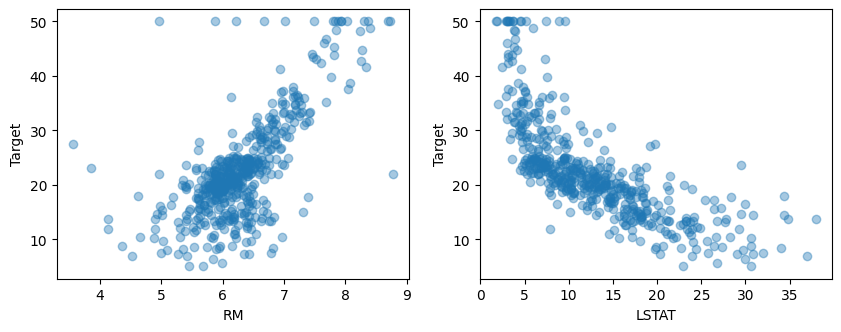

In [3]:
# 상관이 가장 큰 두 변수를 그림으로 봅니다.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, col in zip(axes, ['RM', 'LSTAT']):
    ax.scatter(boston[col], boston['Target'], alpha=0.4)
    ax.set_xlabel(col)
    ax.set_ylabel('Target')

plt.show()

방이 많을수록 비싸고(양의 상관), 하위 계층 비율이 높을수록 쌉니다(음의 상관).
이 관계에 **직선을 하나 그어보자**는 게 선형회귀입니다.

## 1.2.2 선형회귀

$$y = ax + b$$

기울기 $a$와 절편 $b$를 어떻게 정할까요?
실제값과 예측값의 차이를 제곱해서 평균낸 값(**MSE**)이 가장 작아지도록 정합니다.

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

In [4]:
from sklearn.linear_model import LinearRegression

# 방 개수(RM) 하나로만 가격을 예측해 봅니다.
X = boston[['RM']]
y = boston['Target']

reg = LinearRegression()
reg.fit(X, y)

print('기울기:', reg.coef_, '  절편:', reg.intercept_)

기울기: [9.10210898]   절편: -34.67062077643857


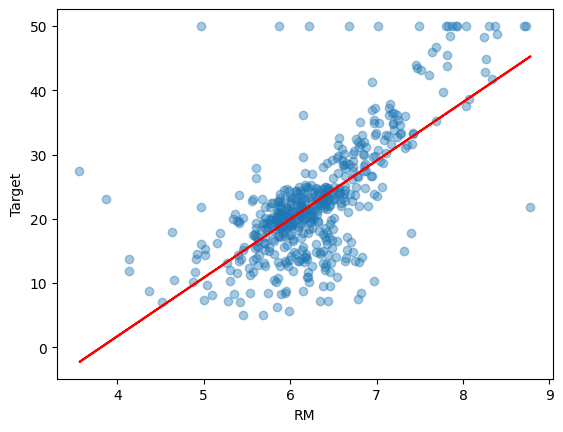

In [5]:
# 찾아낸 직선을 그려봅니다.
plt.scatter(X, y, alpha=0.4)
plt.plot(X, reg.predict(X), 'r')
plt.xlabel('RM')
plt.ylabel('Target')
plt.show()

방이 1개 늘어나면 가격이 약 9(천 달러) 오른다는 뜻입니다.

이제 변수 13개를 **전부** 넣고, 훈련용/테스트용으로 나눠서 제대로 평가해 봅시다.

In [6]:
from sklearn.model_selection import train_test_split

X = boston.drop(columns='Target')
y = boston['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = LinearRegression().fit(X_train, y_train)

print('train 점수:', reg.score(X_train, y_train))
print('test  점수:', reg.score(X_test, y_test))

train 점수: 0.7508856358979673
test  점수: 0.6687594935356326


`score()`는 $R^2$ 점수입니다. 1에 가까울수록 좋고, 0이면 "그냥 평균으로 찍는 것"과 같은 수준입니다.

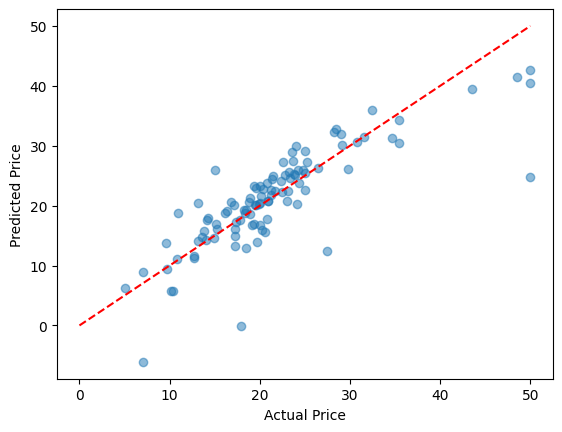

In [7]:
# 실제 가격 vs 예측 가격
plt.scatter(y_test, reg.predict(X_test), alpha=0.5)
plt.plot([0, 50], [0, 50], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

## 1.2.3 정규화(Regularization)

### 과적합부터 만들어 봅시다

변수를 늘릴수록 훈련 데이터는 잘 맞습니다. 그런데 **처음 보는 데이터에서는 오히려 망가질 수** 있습니다.
이게 **과적합(overfitting)** 입니다.

변수끼리 곱한 항까지 넣어서 특성을 559개로 늘려 보겠습니다. (훈련 데이터는 404개뿐입니다!)

In [8]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly = PolynomialFeatures(degree=3, include_bias=False)
scaler = StandardScaler()

X_train_s = scaler.fit_transform(poly.fit_transform(X_train))
X_test_s = scaler.transform(poly.transform(X_test))

X_train_s.shape

(404, 559)

> 변환 기준(평균·표준편차)은 **훈련 데이터로만** 정하고, 테스트에는 `transform`만 적용합니다.
> 정규화는 가중치 크기에 벌점을 주기 때문에 이런 **스케일 맞추기가 필수**입니다.

In [9]:
reg_poly = LinearRegression().fit(X_train_s, y_train)

print('train 점수:', reg_poly.score(X_train_s, y_train))
print('test  점수:', reg_poly.score(X_test_s, y_test))

train 점수: 1.0
test  점수: -223.67149930922102


train은 **1.0** (훈련 데이터를 통째로 외웠다는 뜻), test는 **음수**로 완전히 무너졌습니다.
$R^2$가 음수라는 건 평균으로 찍는 것보다도 못하다는 뜻입니다.

### 해결책: 가중치가 커지지 못하게 막기

$$\text{Ridge: } \text{MSE} + \alpha\sum \beta_j^2
\qquad
\text{Lasso: } \text{MSE} + \alpha\sum |\beta_j|$$

- **릿지(Ridge)**: 가중치를 전체적으로 **작게** 만듦
- **라쏘(Lasso)**: 필요 없는 가중치를 아예 **0으로** 만듦 (변수 선택 효과)

$\alpha$가 클수록 규제가 세집니다.

In [10]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10).fit(X_train_s, y_train)

print('train 점수:', ridge.score(X_train_s, y_train))
print('test  점수:', ridge.score(X_test_s, y_test))

train 점수: 0.9305860560569612
test  점수: 0.8589606564638447


가중치가 커지지 못하게 막았을 뿐인데 test 점수가 **-223에서 0.86으로** 살아났습니다.

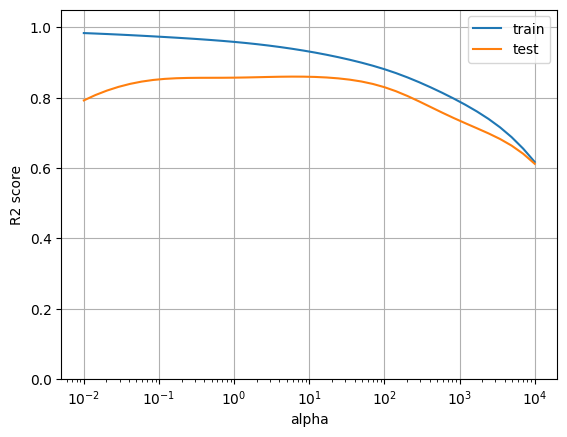

In [11]:
# alpha를 바꿔가며 비교해 봅니다.
alphas = np.logspace(-2, 4, 40)
train_scores, test_scores = [], []

for a in alphas:
    m = Ridge(alpha=a).fit(X_train_s, y_train)
    train_scores.append(m.score(X_train_s, y_train))
    test_scores.append(m.score(X_test_s, y_test))

plt.semilogx(alphas, train_scores, label='train')
plt.semilogx(alphas, test_scores, label='test')
plt.ylim(0, 1.05)
plt.xlabel('alpha')
plt.ylabel('R2 score')
plt.legend()
plt.grid()
plt.show()

왼쪽(규제 약함)은 train만 높은 **과적합**, 오른쪽(규제 셈)은 둘 다 낮은 **과소적합**입니다.
그 사이 어딘가가 가장 좋은 지점입니다.

In [12]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1, max_iter=100000).fit(X_train_s, y_train)

print('test 점수:', lasso.score(X_test_s, y_test))
print(f'사용한 특성: {np.sum(lasso.coef_ != 0)}개 / {len(lasso.coef_)}개')

test 점수: 0.8255558059422986
사용한 특성: 35개 / 559개


In [13]:
# 세 모델 비교
models = {
    'LinearRegression': LinearRegression(),
    'Ridge (alpha=10)': Ridge(alpha=10),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1, max_iter=100000),
}

rows = []
for name, m in models.items():
    m.fit(X_train_s, y_train)
    rows.append({'model': name,
                 'train R2': m.score(X_train_s, y_train),
                 'test R2': m.score(X_test_s, y_test),
                 '사용 특성': int(np.sum(m.coef_ != 0)),
                 '가중치 크기': np.abs(m.coef_).mean()})

pd.DataFrame(rows).set_index('model')

,train R2,test R2,사용 특성,가중치 크기
model,,,,
LinearRegression,1.000000,-223.671499,559,713.418038
Ridge (alpha=10),0.930586,0.858961,559,0.259662
Lasso (alpha=0.1),0.869485,0.825556,35,0.047280


In [14]:
# alpha는 test를 보고 고르면 반칙입니다. 교차검증으로 고릅니다.
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=np.logspace(-2, 4, 40), cv=5).fit(X_train_s, y_train)

print('고른 alpha:', ridge_cv.alpha_)
print('test 점수:', ridge_cv.score(X_test_s, y_test))

고른 alpha: 4.1246263829013525
test 점수: 0.8590671341262016


## 정리

1. 선형회귀는 **MSE를 최소로 만드는 직선(평면)** 을 찾는 것
2. 변수가 많아지면 **과적합** — train은 좋은데 test가 무너짐
3. **정규화**로 가중치 크기에 벌점을 주면 test 성능이 살아남
   - Ridge: 전체적으로 작게 / Lasso: 필요 없는 건 0으로
4. 릿지·라쏘 전에는 **반드시 표준화**, `alpha`는 **교차검증**으로
